# Fashion Product Adoption Experiments

## The purpose of this notebook
USE the simulation to answer our research question

create_network()
       ↓
select_influencer()
       ↓
initialise_customers()
       ↓
┌─────────────────────────┐
│ purchase_probability()  │
│          ↓              │
│ simulation_step()       │ ← repeat over time
└─────────────────────────┘
       ↓
run_simulation()
       ↓
results

## 1. Research Question

How do influencer position and social influence strength affect the adoption of a new fashion product within a consumer social network?



## 2. Model Parameters

Explain the parameters used in the experiments.


### 2.1 Choosing Network Type
We use a Barabási–Albert network as a simplified consumer social network because its heterogeneous degree distribution produces highly connected nodes, allowing controlled comparison of influencer positions.

#### Comparison of Candidate Network Models
| Network | Basic idea | Fit for our project |
|---|---|---|
| Erdős–Rényi random | Connections form randomly with similar opportunity | ⚠️ Usable, but less natural for studying influential hubs |
| Watts–Strogatz small-world | Strong local connections + some long-distance links | ✅ Interesting for social communities |
| **Barabási–Albert** | Some nodes become highly connected hubs | **Selected: provides heterogeneous node degrees suitable for comparing influencer positions** |

### 2.2 Model Assumptions

- At \(t=0\), only the selected influencer has purchased.
- All other customers start with purchased = False.
- Each ordinary customer has an individual baseline purchase probability, assigned once at initialization.
- That baseline stays fixed during one simulation run.
- Customers can later purchase either because of their baseline tendency or because neighbours have purchased.
- Once we implement adoption, we'll likely assume purchase is irreversible (False → True, but never back to False), which we should explicitly decide before finalising the model.

## 3. Baseline Simulation

Run and visualise one simulation to check model behaviour.



### 3.1 Initialisation

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx

project_root = Path.cwd().parent
sys.path.append(str(project_root))

from src.model import (
    create_network,
    select_influencer,
    initialise_customers,
    purchase_probability,
    simulation_step
)

### 3.2 Get the highest degree customer

In [4]:
G = create_network(100, 3)

print("Number of customers:", G.number_of_nodes())
print("Number of connections:", G.number_of_edges())

degrees = dict(G.degree())

highest_degree_customer = max(
    degrees,
    key=degrees.get
)

print("Highest degree customer:", highest_degree_customer)
print("Degree:", G.degree(highest_degree_customer))

Number of customers: 100
Number of connections: 291
Highest degree customer: 4
Degree: 32


In [ ]:
# Test influencer

central_influencer = select_influencer(
    G,
    "central"
)

less_central_influencer = select_influencer(
    G,
    "less_central"
)

print(
    "Central influencer:",
    central_influencer,
    "Degree:",
    G.degree(central_influencer)
)

print(
    "Less-central influencer:",
    less_central_influencer,
    "Degree:",
    G.degree(less_central_influencer)
)

In [ ]:
# Test function - initial influencer
influencer = select_influencer(G, "central")

initialise_customers(G, influencer)

print("Influencer:", influencer)
print(
    "Influencer purchased:",
    G.nodes[influencer]["purchased"]
)


purchased_customers = [
    customer
    for customer in G.nodes()
    if G.nodes[customer]["purchased"]
]

print("Purchased customers:", purchased_customers)
print("Number purchased:", len(purchased_customers))

Influencer: 4
Influencer purchased: True
Purchased customers: [4]
Number purchased: 1


In [2]:
# Test function - purchase_probability
G = create_network(100, 3)

influencer = select_influencer(G, "central")

initialise_customers(G, influencer)

In [3]:
customer = list(G.neighbors(influencer))[0]

print("Influencer:", influencer)
print("Test customer:", customer)
print("Customer degree:", G.degree(customer))

Influencer: 4
Test customer: 0
Customer degree: 25


In [4]:
probability = purchase_probability(
    G,
    customer,
    social_influence=0.5
)

print("Purchase probability:", probability)

Purchase probability: 0.07


In [27]:
# Test one simulation
G = create_network(100, 3)

influencer = select_influencer(
    G,
    "central"
)

initialise_customers(
    G,
    influencer
)

In [28]:
purchased_before = sum(
    G.nodes[customer]["purchased"]
    for customer in G.nodes()
)

print("Purchased before:", purchased_before)

Purchased before: 1


In [29]:
new_purchases = simulation_step(
    G,
    social_influence=0.5
)

print("New purchases:", new_purchases)
print("Number of new purchases:", len(new_purchases))

New purchases: [9, 16, 34, 42, 66, 68, 72, 74, 75, 90, 96, 97, 98]
Number of new purchases: 13


In [30]:
purchased_after = sum(
    G.nodes[customer]["purchased"]
    for customer in G.nodes()
)

print("Purchased after:", purchased_after)

Purchased after: 14


NameError: name 'highest_degree_customer' is not defined

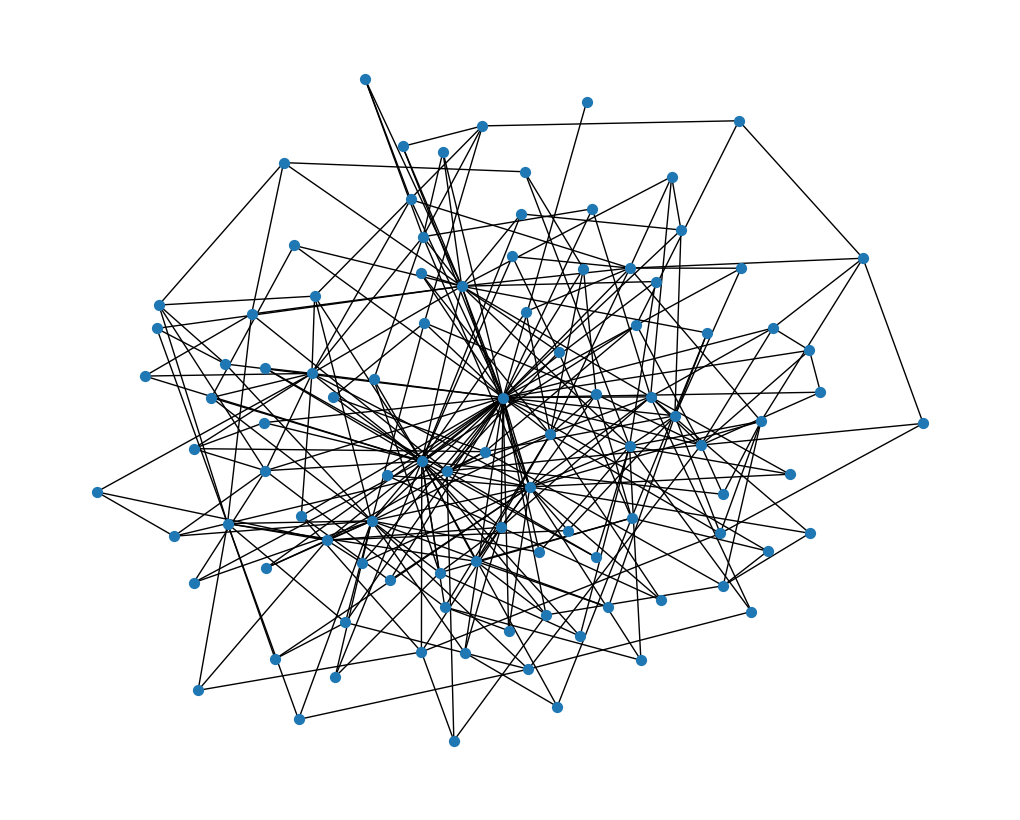

In [31]:
# Calculate positions once
pos = nx.spring_layout(G, seed=42)

plt.figure(figsize=(10, 8))

# Draw the whole network
nx.draw(
    G,
    pos,
    node_size=50,
    with_labels=False
)

# Highlight highest-degree customer
nx.draw_networkx_nodes(
    G,
    pos,
    nodelist=[highest_degree_customer],
    node_size=100,
    node_color="red"
)

plt.title("Customer Social Network")
plt.show()

## 4. Experiment 1 — Influencer Strategy

Compare highly central and less-central influencer placement while controlling other model parameters.



## 5. Experiment 2 — Social Influence Strength

Compare different levels of social influence.



## 6. Results

Analyse final adoption rate and adoption speed.



## 7. Discussion

Explain what the results mean and discuss limitations.